<a href="https://colab.research.google.com/github/sandinaniaaryan-afk/ML/blob/main/lab08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Perceptron & Neural Network Assignment
Simple, function-based implementations for A1–A12 and the Optional section.

**Structure:**
- Section 0: all reusable functions (one code block, as required)
- One section per question (A1 ... A12, O1 ... O3), each with a short markdown note and a 'main program' code cell that calls the functions and prints/plots results
- No `print()` statements live inside any function — only in the main-program cells

## Section 0: Imports and Reusable Functions
Every function needed for the whole assignment lives in this one cell (per instruction: multiple functions are fine, but keep them in a single block).

In [ ]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# A1: Basic perceptron building blocks
# ============================================================

def summation_unit(input_values, weights):
    """Weighted sum. weights[0] is the bias (w0); weights[1:] multiply input_values."""
    total = weights[0]
    for i in range(len(input_values)):
        total = total + (weights[i + 1] * input_values[i])
    return total


def step_activation(y):
    """Unipolar step: 1 if y > 0, else 0."""
    if y > 0:
        return 1
    else:
        return 0


def bipolar_step_activation(y):
    """Bipolar step: 1 if y > 0, -1 if y < 0, 0 if y == 0."""
    if y > 0:
        return 1
    elif y < 0:
        return -1
    else:
        return 0


def sigmoid_activation(y):
    """Sigmoid: 1 / (1 + e^-y)."""
    return 1 / (1 + math.exp(-y))


def tanh_activation(y):
    """Hyperbolic tangent activation."""
    return math.tanh(y)


def relu_activation(y):
    """Rectified Linear Unit: y if y > 0, else 0."""
    if y > 0:
        return y
    else:
        return 0


def leaky_relu_activation(y, alpha=0.01):
    """Leaky ReLU: y if y > 0, else alpha * y."""
    if y > 0:
        return y
    else:
        return alpha * y


def comparator_unit(target_value, predicted_value):
    """Error for a single sample: target - predicted."""
    return target_value - predicted_value


def sum_square_error(target_list, predicted_list):
    """Sum of squared errors across all samples."""
    total_error = 0
    for i in range(len(target_list)):
        total_error = total_error + (target_list[i] - predicted_list[i]) ** 2
    return total_error


# ============================================================
# A2 / A3 / A4 / A5: single-layer perceptron training
# ============================================================

def train_perceptron(input_rows, target_values, initial_weights, learning_rate,
                      activation_function, max_epochs=1000, convergence_error=0.002):
    """
    Trains a single-layer perceptron with the delta learning rule.
    Returns (final_weights, error_per_epoch_list).
    """
    weights = list(initial_weights)
    error_per_epoch = []

    for epoch in range(max_epochs):
        predicted_values = []
        for row_index in range(len(input_rows)):
            y = summation_unit(input_rows[row_index], weights)
            prediction = activation_function(y)
            predicted_values.append(prediction)

            error = comparator_unit(target_values[row_index], prediction)

            weights[0] = weights[0] + (learning_rate * error * 1)
            for j in range(len(input_rows[row_index])):
                weights[j + 1] = weights[j + 1] + (learning_rate * error * input_rows[row_index][j])

        epoch_error = sum_square_error(target_values, predicted_values)
        error_per_epoch.append(epoch_error)

        if epoch_error <= convergence_error:
            break

    return weights, error_per_epoch


def predict_with_weights(input_rows, weights, activation_function):
    """Runs a trained single-layer perceptron over a set of input rows."""
    predictions = []
    for row in input_rows:
        y = summation_unit(row, weights)
        predictions.append(activation_function(y))
    return predictions


def plot_error_curve(error_list, title):
    """Plots sum-square-error against epoch number."""
    plt.figure()
    plt.plot(range(1, len(error_list) + 1), error_list, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Sum Square Error")
    plt.title(title)
    plt.grid(True)
    plt.show()


# ============================================================
# A7: closed-form solution using the Moore-Penrose pseudo-inverse
# ============================================================

def solve_with_pseudo_inverse(input_rows, target_values):
    """Solves W = pinv(X) . T, where X has a leading column of 1s for the bias."""
    X = []
    for row in input_rows:
        X.append([1] + list(row))
    X = np.array(X, dtype=float)
    T = np.array(target_values, dtype=float)
    weights = np.linalg.pinv(X).dot(T)
    return weights


# ============================================================
# A8 / A9 / A10: two-layer network trained with back-propagation
# ============================================================

def forward_pass(input_row, V, W):
    """
    One forward pass through a 2-layer sigmoid network.
    V: hidden-layer weights, shape (n_inputs+1, n_hidden), row 0 = bias.
    W: output-layer weights, shape (n_hidden+1, n_outputs), row 0 = bias.
    Returns (hidden_outputs, final_outputs).
    """
    x_with_bias = [1] + list(input_row)
    hidden_outputs = []
    for h in range(V.shape[1]):
        y_h = 0
        for i in range(len(x_with_bias)):
            y_h = y_h + (x_with_bias[i] * V[i][h])
        hidden_outputs.append(sigmoid_activation(y_h))

    hidden_with_bias = [1] + hidden_outputs
    final_outputs = []
    for o in range(W.shape[1]):
        y_o = 0
        for h in range(len(hidden_with_bias)):
            y_o = y_o + (hidden_with_bias[h] * W[h][o])
        final_outputs.append(sigmoid_activation(y_o))

    return hidden_outputs, final_outputs


def train_backprop_network(input_rows, target_rows, n_hidden, learning_rate,
                            max_epochs=1000, convergence_error=0.002, seed=1):
    """
    Trains a one-hidden-layer sigmoid network with back-propagation
    (update rules T4.3 - T4.5, Tom Mitchell, Table 4.2).
    Returns (V, W, error_per_epoch_list).
    """
    rng = np.random.RandomState(seed)
    n_inputs = len(input_rows[0])
    n_outputs = len(target_rows[0])

    V = rng.uniform(-0.05, 0.05, size=(n_inputs + 1, n_hidden))
    W = rng.uniform(-0.05, 0.05, size=(n_hidden + 1, n_outputs))

    error_per_epoch = []

    for epoch in range(max_epochs):
        all_predictions = []
        for row_index in range(len(input_rows)):
            x_with_bias = [1] + list(input_rows[row_index])
            hidden_outputs, final_outputs = forward_pass(input_rows[row_index], V, W)
            all_predictions.append(final_outputs)
            targets = target_rows[row_index]

            # output layer error terms (T4.3)
            delta_output = []
            for k in range(len(final_outputs)):
                o_k = final_outputs[k]
                delta_output.append(o_k * (1 - o_k) * (targets[k] - o_k))

            # hidden layer error terms (T4.4)
            hidden_with_bias = [1] + hidden_outputs
            delta_hidden = []
            for h in range(len(hidden_outputs)):
                o_h = hidden_outputs[h]
                weighted_sum = 0
                for k in range(len(delta_output)):
                    weighted_sum = weighted_sum + (W[h + 1][k] * delta_output[k])
                delta_hidden.append(o_h * (1 - o_h) * weighted_sum)

            # update output weights W (T4.5)
            for h in range(len(hidden_with_bias)):
                for k in range(len(delta_output)):
                    W[h][k] = W[h][k] + (learning_rate * delta_output[k] * hidden_with_bias[h])

            # update hidden weights V (T4.5)
            for i in range(len(x_with_bias)):
                for h in range(len(delta_hidden)):
                    V[i][h] = V[i][h] + (learning_rate * delta_hidden[h] * x_with_bias[i])

        epoch_error = 0
        for row_index in range(len(target_rows)):
            for k in range(len(target_rows[row_index])):
                epoch_error = epoch_error + (target_rows[row_index][k] - all_predictions[row_index][k]) ** 2
        error_per_epoch.append(epoch_error)

        if epoch_error <= convergence_error:
            break

    return V, W, error_per_epoch


# ============================================================
# A12: RAVDESS feature extraction helpers
# ============================================================

RAVDESS_EMOTION_MAP = {
    "01": "neutral", "02": "calm", "03": "happy", "04": "sad",
    "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"
}


def get_emotion_from_filename(file_name):
    """RAVDESS files look like 03-01-06-01-02-01-12.wav; the 3rd field is the emotion code."""
    code_value = file_name.split("-")[2]
    return RAVDESS_EMOTION_MAP.get(code_value, "unknown")


def extract_mfcc_features(file_path, n_mfcc=40):
    """Loads one audio file and returns the mean of its MFCC coefficients as a feature vector."""
    import librosa
    audio_signal, sample_rate = librosa.load(file_path, sr=None)
    mfcc_matrix = librosa.feature.mfcc(y=audio_signal, sr=sample_rate, n_mfcc=n_mfcc)
    mfcc_mean = np.mean(mfcc_matrix, axis=1)
    return mfcc_mean


def build_dataset_from_folder(root_folder, n_mfcc=40):
    """
    Walks the RAVDESS folder structure (Actor_01, Actor_02, ...), extracts MFCC
    features for every .wav file, and returns (feature_matrix, label_array).
    """
    feature_rows = []
    label_rows = []
    for current_dir, _, file_names in os.walk(root_folder):
        for file_name in file_names:
            if file_name.endswith(".wav"):
                full_path = os.path.join(current_dir, file_name)
                features = extract_mfcc_features(full_path, n_mfcc)
                feature_rows.append(features)
                label_rows.append(get_emotion_from_filename(file_name))
    return np.array(feature_rows), np.array(label_rows)


## A1: Summation, Activation and Comparator units
Just a quick demonstration that each modular function works on a single sample.

In [ ]:
# ---- Main program: A1 ----
sample_inputs = [1, 0]
sample_weights = [10, 0.2, -0.75]   # W0, W1, W2 given in the problem

y = summation_unit(sample_inputs, sample_weights)

print("Summation output (y)   :", y)
print("Step activation         :", step_activation(y))
print("Bi-Polar Step activation:", bipolar_step_activation(y))
print("Sigmoid activation      :", sigmoid_activation(y))
print("TanH activation         :", tanh_activation(y))
print("ReLU activation         :", relu_activation(y))
print("Leaky ReLU activation   :", leaky_relu_activation(y))
print("Comparator (target=1)   :", comparator_unit(1, step_activation(y)))


Summation output (y)   : 10.2
Step activation         : 1
Bi-Polar Step activation: 1
Sigmoid activation      : 0.9999628310628971
TanH activation         : 0.9999999972367348
ReLU activation         : 10.2
Leaky ReLU activation   : 10.2
Comparator (target=1)   : 0


## A2: Perceptron learning for the AND gate (Step activation)
W0=10, W1=0.2, W2=-0.75, learning rate = 0.05. Converged when SSE ≤ 0.002, capped at 1000 epochs.

Final weights               : [-0.10000000000000765, 0.1000000000000001, 0.05000000000000032]
Number of epochs to converge: 130


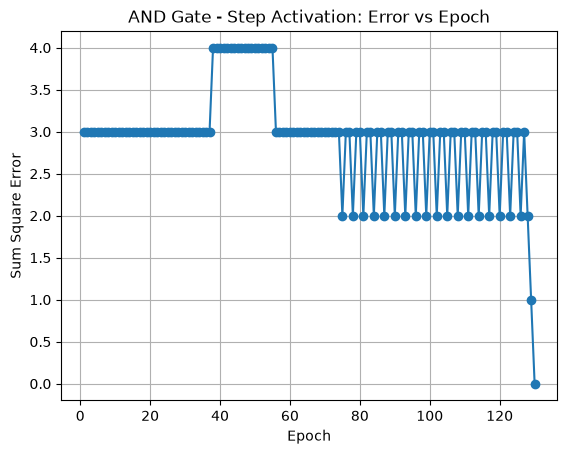

In [ ]:
# ---- Main program: A2 ----
and_inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]
and_targets = [0, 0, 0, 1]
initial_weights = [10, 0.2, -0.75]
learning_rate = 0.05

final_weights, error_history = train_perceptron(
    and_inputs, and_targets, initial_weights, learning_rate, step_activation
)

print("Final weights               :", final_weights)
print("Number of epochs to converge:", len(error_history))
plot_error_curve(error_history, "AND Gate - Step Activation: Error vs Epoch")


## A3: Repeat A1/A2 with Bi-Polar Step, Sigmoid and ReLU activations
For the bi-polar step activation the AND-gate targets are re-coded to {-1, 1} since that activation never outputs 0/1.

Epochs to converge - Bi-Polar Step: 68
Epochs to converge - Sigmoid      : 1000
Epochs to converge - ReLU         : 390


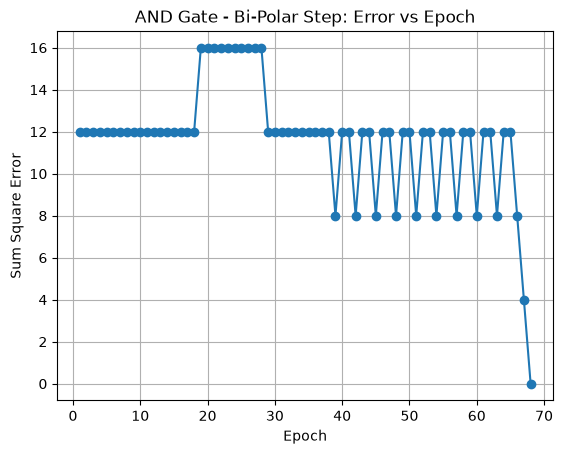

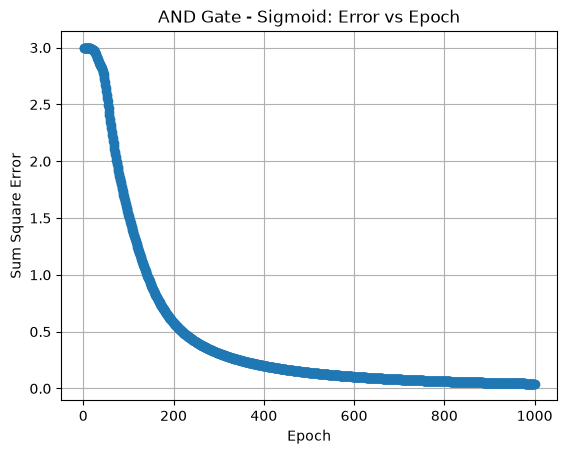

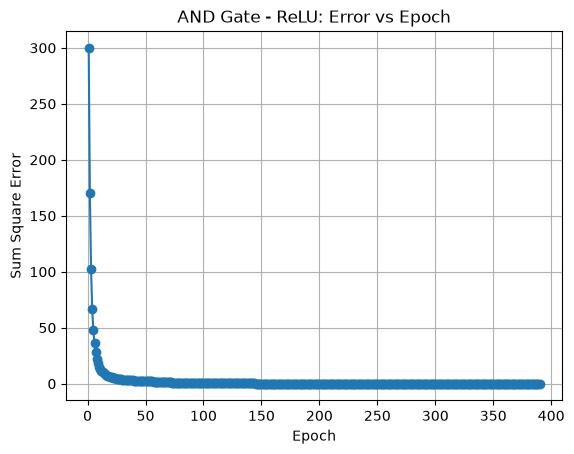

In [ ]:
# ---- Main program: A3 ----
and_targets_bipolar = [-1, -1, -1, 1]

_, errors_bipolar = train_perceptron(
    and_inputs, and_targets_bipolar, initial_weights, learning_rate, bipolar_step_activation
)
_, errors_sigmoid = train_perceptron(
    and_inputs, and_targets, initial_weights, learning_rate, sigmoid_activation
)
_, errors_relu = train_perceptron(
    and_inputs, and_targets, initial_weights, learning_rate, relu_activation
)

print("Epochs to converge - Bi-Polar Step:", len(errors_bipolar))
print("Epochs to converge - Sigmoid      :", len(errors_sigmoid))
print("Epochs to converge - ReLU         :", len(errors_relu))

plot_error_curve(errors_bipolar, "AND Gate - Bi-Polar Step: Error vs Epoch")
plot_error_curve(errors_sigmoid, "AND Gate - Sigmoid: Error vs Epoch")
plot_error_curve(errors_relu, "AND Gate - ReLU: Error vs Epoch")


## A4: Effect of learning rate on convergence speed (Step activation, AND gate)

Learning rate 0.1: 68 epochs
Learning rate 0.2: 37 epochs
Learning rate 0.3: 23 epochs
Learning rate 0.4: 23 epochs
Learning rate 0.5: 20 epochs
Learning rate 0.6: 19 epochs
Learning rate 0.7: 15 epochs
Learning rate 0.8: 14 epochs
Learning rate 0.9: 13 epochs
Learning rate 1.0: 14 epochs


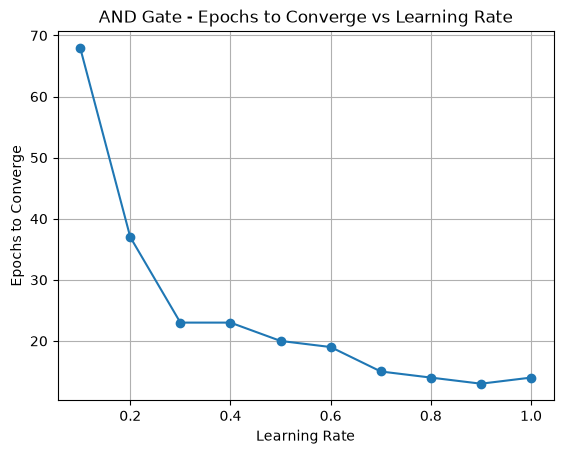

In [ ]:
# ---- Main program: A4 ----
learning_rates = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
epochs_needed = []

for lr in learning_rates:
    _, errors = train_perceptron(and_inputs, and_targets, initial_weights, lr, step_activation)
    epochs_needed.append(len(errors))

for lr, epochs in zip(learning_rates, epochs_needed):
    print(f"Learning rate {lr}: {epochs} epochs")

plt.figure()
plt.plot(learning_rates, epochs_needed, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Epochs to Converge")
plt.title("AND Gate - Epochs to Converge vs Learning Rate")
plt.grid(True)
plt.show()


## A5: Repeat A1-A3 for XOR gate logic
**Expected outcome:** a single-layer perceptron cannot separate XOR (it is not linearly separable), so the error will not reach 0.002 for any activation — training simply stops at the 1000-epoch cap. This motivates the multi-layer network built in A8/A9.

XOR - Step        : ran 1000 epochs, final error = 4
XOR - Bi-Polar Step: ran 1000 epochs, final error = 16
XOR - Sigmoid      : ran 1000 epochs, final error = 1.025
XOR - ReLU         : ran 1000 epochs, final error = 1.108


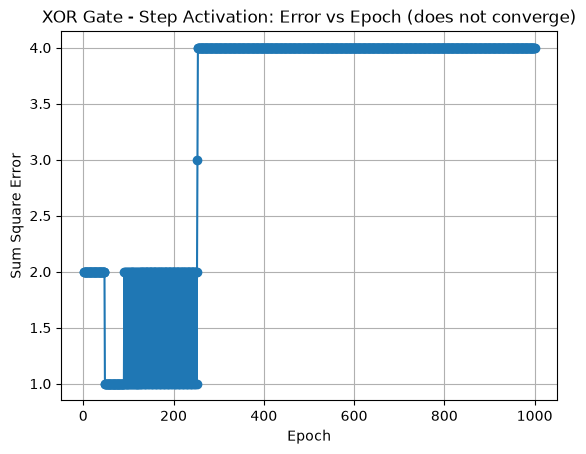

In [ ]:
# ---- Main program: A5 ----
xor_inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]
xor_targets = [0, 1, 1, 0]
xor_targets_bipolar = [-1, 1, 1, -1]

_, xor_errors_step = train_perceptron(xor_inputs, xor_targets, initial_weights, learning_rate, step_activation)
_, xor_errors_bipolar = train_perceptron(xor_inputs, xor_targets_bipolar, initial_weights, learning_rate, bipolar_step_activation)
_, xor_errors_sigmoid = train_perceptron(xor_inputs, xor_targets, initial_weights, learning_rate, sigmoid_activation)
_, xor_errors_relu = train_perceptron(xor_inputs, xor_targets, initial_weights, learning_rate, relu_activation)

print("XOR - Step        : ran", len(xor_errors_step), "epochs, final error =", round(xor_errors_step[-1], 3))
print("XOR - Bi-Polar Step: ran", len(xor_errors_bipolar), "epochs, final error =", round(xor_errors_bipolar[-1], 3))
print("XOR - Sigmoid      : ran", len(xor_errors_sigmoid), "epochs, final error =", round(xor_errors_sigmoid[-1], 3))
print("XOR - ReLU         : ran", len(xor_errors_relu), "epochs, final error =", round(xor_errors_relu[-1], 3))

plot_error_curve(xor_errors_step, "XOR Gate - Step Activation: Error vs Epoch (does not converge)")


## A6: Perceptron on customer transaction data (Sigmoid activation)
Features are z-score normalised so the sigmoid perceptron trains smoothly. Weights are initialised to 0 and learning rate is chosen as 0.1.

Final weights: [1.941, -0.046, 4.311, 0.154, 4.844]
Epochs run   : 334


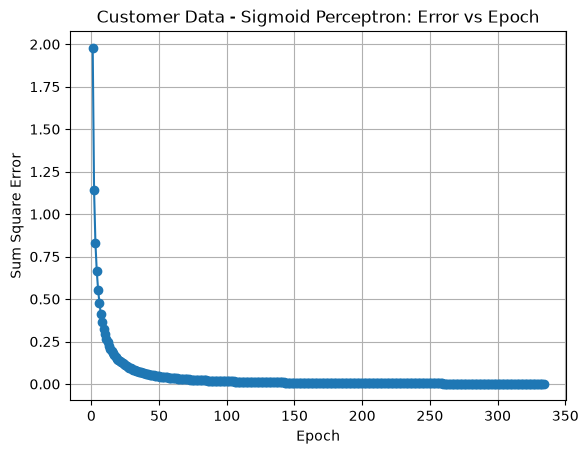

In [ ]:
# ---- Main program: A6 ----
customer_data = {
    "Candies": [20, 16, 27, 19, 24, 22, 15, 18, 21, 16],
    "Mangoes": [6, 3, 6, 1, 4, 1, 4, 4, 1, 2],
    "MilkPackets": [2, 6, 2, 2, 2, 5, 2, 2, 4, 4],
    "Payment": [386, 289, 393, 110, 280, 167, 271, 274, 148, 198],
    "HighValue": ["Yes", "Yes", "Yes", "No", "Yes", "No", "Yes", "Yes", "No", "No"],
}
customer_df = pd.DataFrame(customer_data, index=["C_" + str(i + 1) for i in range(10)])
customer_df["Target"] = customer_df["HighValue"].apply(lambda label: 1 if label == "Yes" else 0)

feature_columns = ["Candies", "Mangoes", "MilkPackets", "Payment"]
normalized_features = (customer_df[feature_columns] - customer_df[feature_columns].mean()) / customer_df[feature_columns].std()

customer_inputs = normalized_features.values.tolist()
customer_targets = customer_df["Target"].tolist()

customer_initial_weights = [0.0, 0.0, 0.0, 0.0, 0.0]   # bias + 4 feature weights
customer_learning_rate = 0.1

customer_weights, customer_errors = train_perceptron(
    customer_inputs, customer_targets, customer_initial_weights,
    customer_learning_rate, sigmoid_activation, max_epochs=1000, convergence_error=0.002
)

print("Final weights:", [round(w, 3) for w in customer_weights])
print("Epochs run   :", len(customer_errors))
plot_error_curve(customer_errors, "Customer Data - Sigmoid Perceptron: Error vs Epoch")


## A7: Compare perceptron learning to the pseudo-inverse (closed-form) solution

In [ ]:
# ---- Main program: A7 ----
pinv_weights = solve_with_pseudo_inverse(customer_inputs, customer_targets)

perceptron_predictions = predict_with_weights(customer_inputs, customer_weights, sigmoid_activation)
pinv_predictions = predict_with_weights(customer_inputs, pinv_weights, sigmoid_activation)

comparison_df = pd.DataFrame({
    "Customer": customer_df.index,
    "Actual": customer_targets,
    "Perceptron_Pred": [round(p, 3) for p in perceptron_predictions],
    "PseudoInverse_Pred": [round(p, 3) for p in pinv_predictions],
})

print("Pseudo-inverse weights:", [round(w, 3) for w in pinv_weights])
print(comparison_df.to_string(index=False))


Pseudo-inverse weights: [np.float64(0.6), np.float64(-0.099), np.float64(0.229), np.float64(-0.014), np.float64(0.247)]
Customer  Actual  Perceptron_Pred  PseudoInverse_Pred
     C_1       1            1.000               0.783
     C_2       1            0.977               0.678
     C_3       1            1.000               0.754
     C_4       0            0.000               0.501
     C_5       1            0.993               0.661
     C_6       0            0.001               0.511
     C_7       1            0.991               0.707
     C_8       1            0.992               0.692
     C_9       0            0.000               0.508
    C_10       0            0.035               0.601


## A8: Two-layer network (2 inputs -> 2 hidden units -> 1 output) with back-propagation, AND gate
Sigmoid activation, learning rate = 0.05.

Epochs to converge: 1000
Final hidden-layer weights (V):
 [[ 0.05195428  0.07185815]
 [-0.55595791 -0.52047787]
 [-0.53999183 -0.54149256]]
Final output-layer weights (W):
 [[-0.45973263]
 [-0.80594814]
 [-0.77677028]]


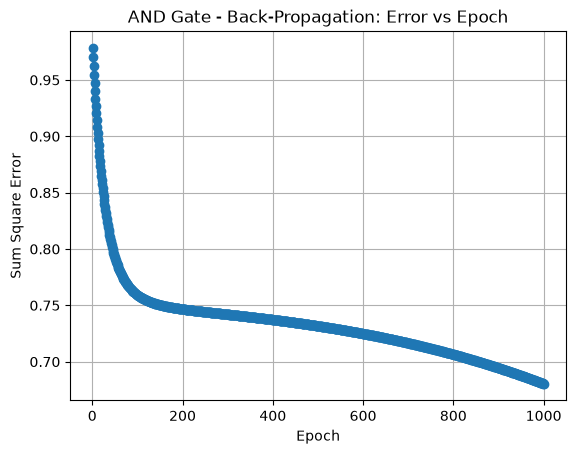

In [ ]:
# ---- Main program: A8 ----
and_targets_2d = [[t] for t in and_targets]   # each target as a 1-element list, one per output node

V_and, W_and, bp_errors_and = train_backprop_network(
    and_inputs, and_targets_2d, n_hidden=2, learning_rate=0.05,
    max_epochs=1000, convergence_error=0.002
)

print("Epochs to converge:", len(bp_errors_and))
print("Final hidden-layer weights (V):\n", V_and)
print("Final output-layer weights (W):\n", W_and)
plot_error_curve(bp_errors_and, "AND Gate - Back-Propagation: Error vs Epoch")


## A9: Repeat A8 for XOR gate logic
With a hidden layer the network is *capable* of learning XOR, unlike the single-layer perceptron in A5 — but note that back-propagation with small random initial weights and this learning rate can genuinely need more than 1000 epochs to satisfy the strict 0.002 threshold. If the run below stops at the 1000-epoch cap with the error still falling, that is expected; try a higher learning rate or more epochs to see full convergence.

Epochs run  : 1000
Final error : 1.00463


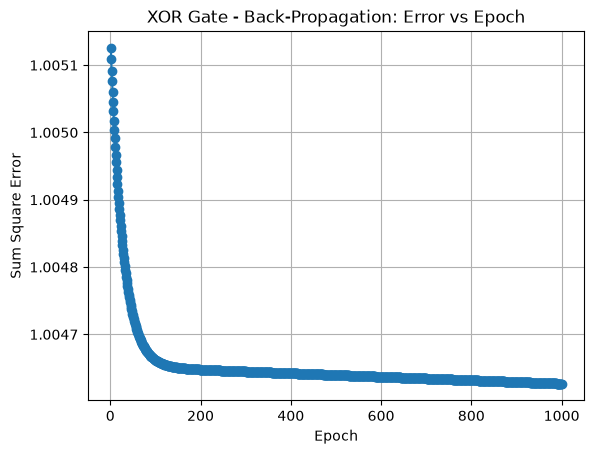

In [ ]:
# ---- Main program: A9 ----
xor_targets_2d = [[t] for t in xor_targets]

V_xor, W_xor, bp_errors_xor = train_backprop_network(
    xor_inputs, xor_targets_2d, n_hidden=2, learning_rate=0.05,
    max_epochs=1000, convergence_error=0.002
)

print("Epochs run  :", len(bp_errors_xor))
print("Final error :", round(bp_errors_xor[-1], 5))
plot_error_curve(bp_errors_xor, "XOR Gate - Back-Propagation: Error vs Epoch")


## A10: Repeat A1 & A2 with 2 output nodes
One-hot target encoding: gate output 0 -> [1, 0], gate output 1 -> [0, 1]. Same back-propagation network as A8/A9, just with 2 output units.

Epochs to converge: 1000


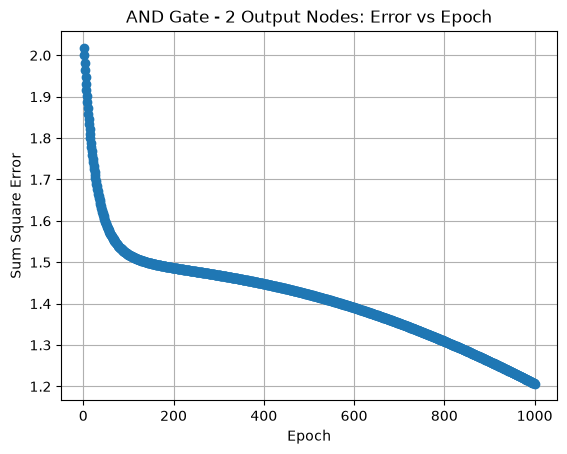

In [ ]:
# ---- Main program: A10 ----
and_targets_onehot = [[1, 0] if t == 0 else [0, 1] for t in and_targets]

V_and2, W_and2, bp_errors_and2 = train_backprop_network(
    and_inputs, and_targets_onehot, n_hidden=2, learning_rate=0.05,
    max_epochs=1000, convergence_error=0.002
)

print("Epochs to converge:", len(bp_errors_and2))
plot_error_curve(bp_errors_and2, "AND Gate - 2 Output Nodes: Error vs Epoch")


## A11: Same AND / XOR problems using Scikit-learn's `MLPClassifier`
The `lbfgs` solver is used because the dataset has only 4 samples — gradient-descent-style solvers (`adam`/`sgd`) are built for large batches and are unreliable on datasets this tiny.

In [ ]:
# ---- Main program: A11 ----
from sklearn.neural_network import MLPClassifier

and_X, and_y = np.array(and_inputs), np.array(and_targets)
xor_X, xor_y = np.array(xor_inputs), np.array(xor_targets)

and_mlp = MLPClassifier(hidden_layer_sizes=(4,), activation="logistic", solver="lbfgs",
                         learning_rate_init=0.05, max_iter=5000, random_state=1)
and_mlp.fit(and_X, and_y)

xor_mlp = MLPClassifier(hidden_layer_sizes=(4,), activation="logistic", solver="lbfgs",
                         learning_rate_init=0.05, max_iter=5000, random_state=1)
xor_mlp.fit(xor_X, xor_y)

print("AND gate predictions:", and_mlp.predict(and_X), " | accuracy:", and_mlp.score(and_X, and_y))
print("XOR gate predictions:", xor_mlp.predict(xor_X), " | accuracy:", xor_mlp.score(xor_X, xor_y))


AND gate predictions: [0 0 0 1]  | accuracy: 1.0
XOR gate predictions: [0 1 1 0]  | accuracy: 1.0


## A12: `MLPClassifier` on the RAVDESS project dataset (speech-emotion recognition)
This extracts MFCC (Mel-Frequency Cepstral Coefficient) features from each `.wav` file — one 40-number feature vector per clip — and trains an MLP to classify the 8 RAVDESS emotions.

**Before running:** `pip install librosa soundfile` in your VS Code environment, and set `ravdess_folder_path` below to the folder that directly contains your `Actor_01 ... Actor_24` sub-folders.

In [ ]:
# ---- Main program: A12 ----
ravdess_folder_path = "ravdess"   # <-- change this to your dataset location

if os.path.exists(ravdess_folder_path):
    X_ravdess, y_ravdess = build_dataset_from_folder(ravdess_folder_path)

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    X_train, X_test, y_train, y_test = train_test_split(
        X_ravdess, y_ravdess, test_size=0.2, random_state=1, stratify=y_ravdess
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    ravdess_mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                                 learning_rate_init=0.001, max_iter=500, random_state=1)
    ravdess_mlp.fit(X_train_scaled, y_train)

    print("Number of samples used:", len(y_ravdess))
    print("Training accuracy     :", round(ravdess_mlp.score(X_train_scaled, y_train), 3))
    print("Test accuracy         :", round(ravdess_mlp.score(X_test_scaled, y_test), 3))
else:
    print("Set 'ravdess_folder_path' above to the folder containing Actor_01..Actor_24, then re-run this cell.")


NameError: name 'os' is not defined